
# 📊 Projeto: Análise da Escolaridade no Brasil
Objetivo: Identificar desigualdades educacionais utilizando dados do IBGE


In [1]:
# Importação de bibliotecas

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Upload do arquivo CSV no Colab

from google.colab import files
uploaded = files.upload("escolaridade.csv")

# 1 - Carregamento dos Dados

In [ ]:
# Leitura do arquivo CSV (ignorando linhas iniciais de metadados)
df = pd.read_csv("escolaridade.csv/escolaridade.csv", sep=";", skiprows=6)

# Visualização inicial dos dados
print(df.head())
print(df.columns)

#2 - Detecção de dados faltantes

In [ ]:
# Verificando valores ausentes no dataset
print(df.isnull().sum())


# 3 - Limpeza e tratamento dos dados

In [6]:
# Substituindo valores inválidos ("-") por NaN
df.replace("-", pd.NA, inplace=True)

# Convertendo colunas numéricas (evitando erros com dados inválidos)
cols_numericas = df.columns[3:]
for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Renomeando colunas para melhor interpretação
df.columns = [
    "Regiao", "Cor", "Idade",
    "Total_geral", "Homens_total", "Mulheres_total",
    "Fund_inc", "Homens_fund_inc", "Mulheres_fund_inc",
    "Fund_comp", "Homens_fund_comp", "Mulheres_fund_comp",
    "Med_sup", "Homens_med_sup", "Mulheres_med_sup"
]


# 4 - Padronização de variáveis categóricas

In [7]:
# Removendo espaços e padronizando texto
df["Cor"] = df["Cor"].str.strip().str.lower()
df["Regiao"] = df["Regiao"].str.strip()
df["Cor"] = df["Cor"].str.capitalize()


# 5 - Verificação de consistência dos dados

In [ ]:
# Conferindo se Total = Homens + Mulheres
inconsistencias = (df["Total_geral"] != df["Homens_total"] + df["Mulheres_total"]).sum()
print(f"Inconsistências encontradas: {inconsistencias}")

# Insight técnico:
Essa verificação garante a integridade dos dados antes da análise,
evitando conclusões incorretas baseadas em dados inconsistentes.


# 6 - Engenharia de atributos

In [9]:
# Criando variável de proporção de homens
df["prop_homens"] = df["Homens_total"] / df["Total_geral"]

# Filtrando dados totais (todas as idades)
df_total = df[df["Idade"] == "Total"]


# 7 - Análise Exploratória de Dados (EDA)
📊 Gráfico 1: Escolaridade por raça/cor

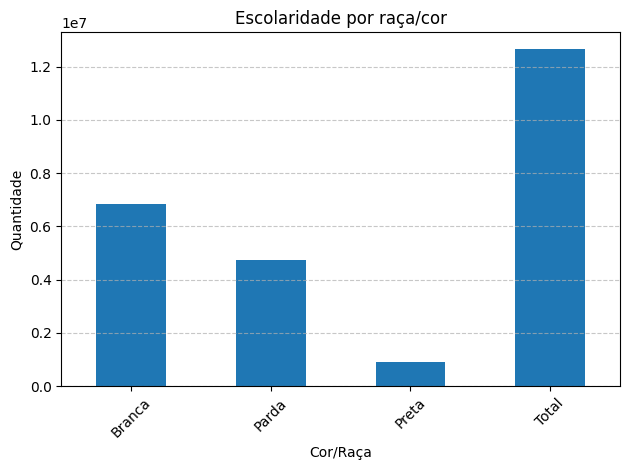

In [10]:
df_cor = df_total.groupby("Cor")["Med_sup"].mean()

plt.figure()
df_cor.plot(kind="bar")
plt.title("Escolaridade por raça/cor")
plt.xlabel("Cor/Raça")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



# Insight:
Este gráfico permite identificar desigualdades raciais na escolaridade.
Em geral, observa-se que determinados grupos (como pretos e pardos)
tendem a apresentar menor acesso a níveis mais elevados de educação.


 📊 Gráfico 2: Comparação entre homens e mulheres

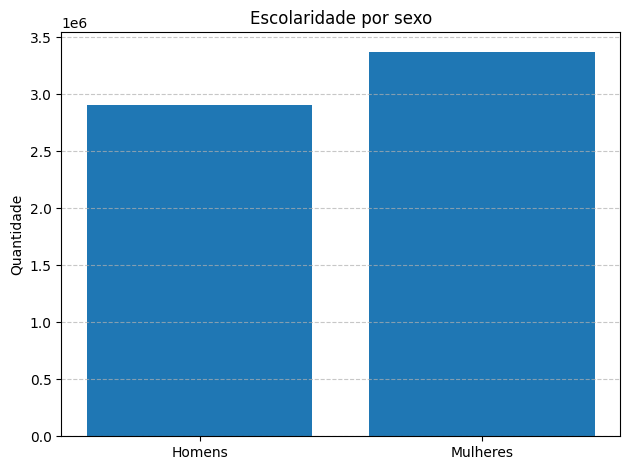

In [11]:
df_sexo = df[df["Idade"] == "Total"]
media_homens = df_sexo["Homens_med_sup"].mean()
media_mulheres = df_sexo["Mulheres_med_sup"].mean()

plt.figure()
plt.bar(["Homens", "Mulheres"], [media_homens, media_mulheres])
plt.title("Escolaridade por sexo")
plt.ylabel("Quantidade")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



# Insight:
A diferença entre homens e mulheres tende a ser menor quando comparada
a outros fatores como região e raça/cor, embora ainda reflita padrões sociais.

 📊 Gráfico 3: Escolaridade por região

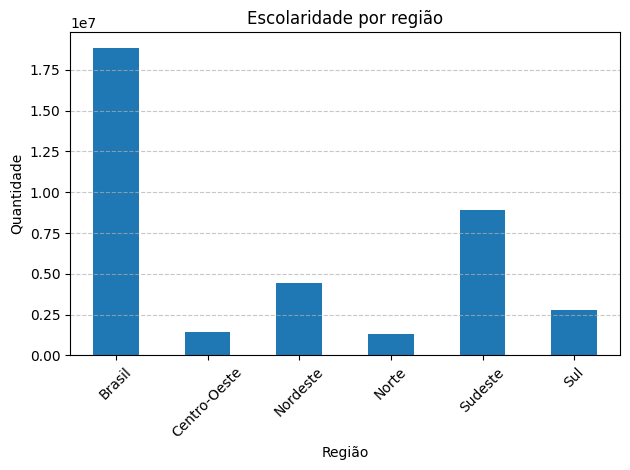

In [12]:
df_regiao = df[df["Idade"] == "Total"].groupby("Regiao")["Med_sup"].mean()

plt.figure()
df_regiao.plot(kind="bar")
plt.title("Escolaridade por região")
plt.xlabel("Região")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



# Insight:
Regiões Sudeste e Sul geralmente apresentam maiores níveis de escolaridade,
enquanto Norte e Nordeste apresentam menores índices,
evidenciando desigualdade regional no acesso à educação.

 📊 Gráfico 4: Jovens vs escolaridade

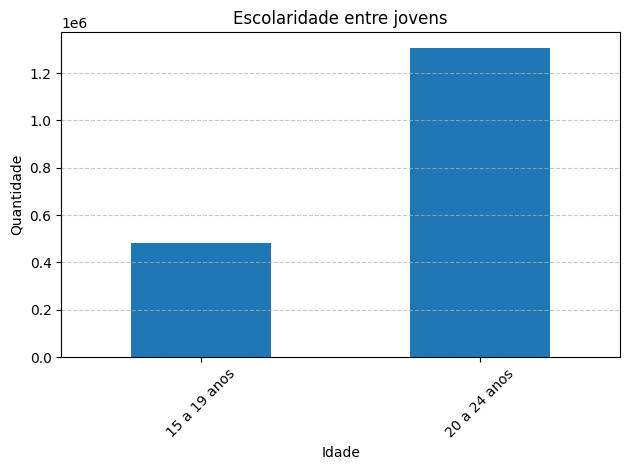

In [13]:
df_jovens = df[df["Idade"].isin(["15 a 19 anos", "20 a 24 anos"])]

plt.figure()
df_jovens.groupby("Idade")["Med_sup"].mean().plot(kind="bar")
plt.title("Escolaridade entre jovens")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



# Insight:
A análise por faixa etária permite observar diferenças geracionais.
Jovens tendem a apresentar padrões distintos de escolaridade,
refletindo mudanças no acesso à educação ao longo do tempo.